# 🛰️ SafeOrbit — Classificação de Terreno por Visão Computacional

### Global Solution — Indústria Espacial · Applied Computer Vision

Integrantes do grupo:

| Nome | RM |
|------|----|
| Breno Silva Rubio | RM97864 |
| Enrico Marquez | RM99325 |
| Gustavo Dias | RM550820 |
| Joel Barros | RM550378 |
| Leonardo Moreira | RM550988 |



## 1. Definição do problema de Visão Computacional

O **SafeOrbit** é uma plataforma de **coordenação de resgate em áreas remotas via
constelação de satélites LEO**. Quando alguém em perigo dispara um sinal de SOS, um
satélite retransmite a localização ao nosso centro de operações na nuvem.

Saber *onde* a pessoa está não basta — a equipe precisa saber **em que terreno** ela
está, pois isso muda a estratégia (helicóptero? barco? trilha a pé? apoio de moradores?).

**Problema de classificação:** dada a imagem de satélite (tile RGB) da coordenada do
sinal, classificar o **tipo de cobertura/terreno** entre 10 classes.

**Conexão espacial:** usamos imagens reais do satélite **Sentinel-2** (Copernicus/ESA),
dado orbital aberto. **ODS:** 9, 11, 3 e 10.

## 2. Preparação do ambiente

In [21]:
# A biblioteca 'datasets' (Hugging Face) baixa o EuroSAT de um espelho confiável.
# (O servidor original madm.dfki.de costuma dar erro 403; por isso NÃO usamos tfds.)
!pip install -q datasets

In [22]:
import os, json, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from PIL import Image

SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU disponível:", "SIM ✅" if tf.config.list_physical_devices('GPU') else "NÃO ❌ (ative em Ambiente de execução → GPU)")

TensorFlow: 2.20.0
GPU disponível: SIM ✅


## 3. Dataset — EuroSAT (Sentinel-2)

**27.000** imagens RGB de **64×64 px**, **10 classes** de terreno, do satélite Sentinel-2.
Baixado da Hugging Face (`blanchon/EuroSAT_RGB`), já dividido em **treino / validação / teste**
(≈ 16.200 / 5.400 / 5.400 — proporção ~60/20/20).

In [23]:
# Baixa o EuroSAT RGB (~174 MB). Na 1ª vez leva ~1-2 min.
ds = load_dataset("blanchon/EuroSAT_RGB")
CLASS_NAMES = ds["train"].features["label"].names
NUM_CLASSES = len(CLASS_NAMES)
print(ds)
print("Classes:", CLASS_NAMES)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


In [24]:
# Converte as imagens (PIL) para arrays numpy normalizados em [0,1]
IMG_SIZE = 64

def to_arrays(split):
    X = np.stack([np.asarray(im.convert("RGB"), dtype="float32") for im in split["image"]]) / 255.0
    y = np.asarray(split["label"], dtype="int64")
    return X, y

X_train, y_train = to_arrays(ds["train"])
X_val,   y_val   = to_arrays(ds["validation"])
X_test,  y_test  = to_arrays(ds["test"])
print("Treino:", X_train.shape, "| Validação:", X_val.shape, "| Teste:", X_test.shape)

Treino: (16200, 64, 64, 3) | Validação: (5400, 64, 64, 3) | Teste: (5400, 64, 64, 3)


### 3.1 Explorando o dataset

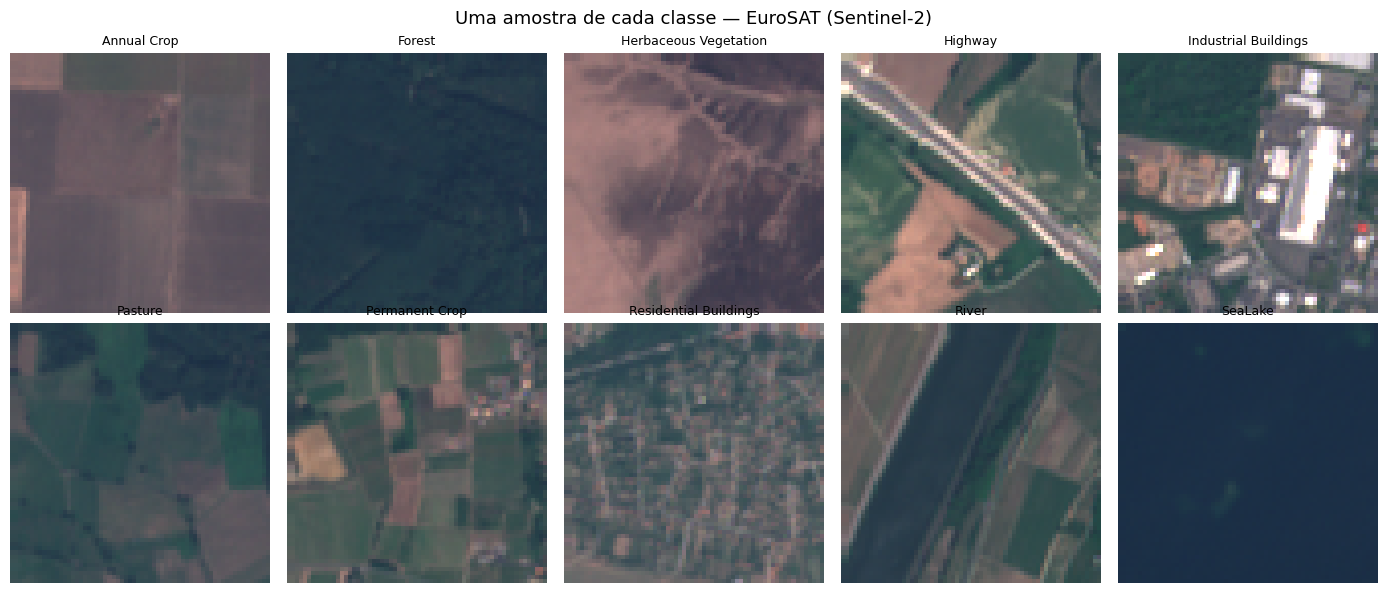

In [25]:
# Uma amostra de cada classe
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for c, ax in enumerate(axes.flat):
    idx = np.where(y_train == c)[0][0]
    ax.imshow(X_train[idx]); ax.set_title(CLASS_NAMES[c], fontsize=9); ax.axis("off")
plt.suptitle("Uma amostra de cada classe — EuroSAT (Sentinel-2)", fontsize=13)
plt.tight_layout(); plt.show()

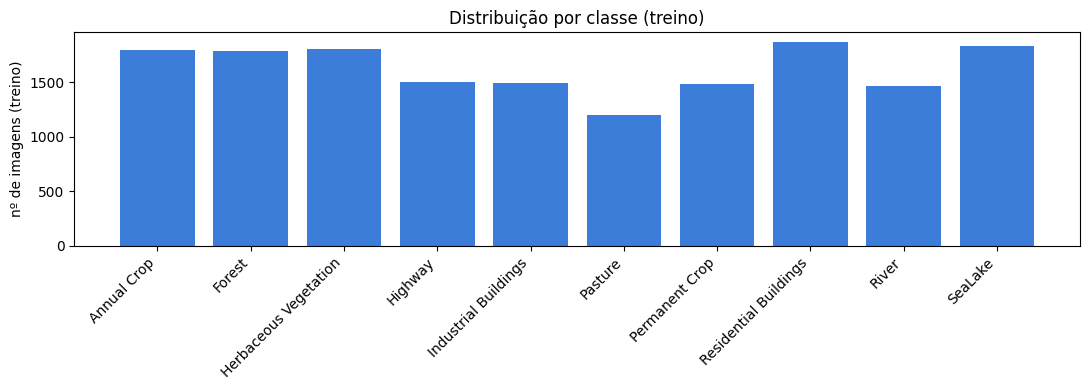

Annual Crop             1791
Forest                  1787
Herbaceous Vegetation   1799
Highway                 1505
Industrial Buildings    1492
Pasture                 1195
Permanent Crop          1481
Residential Buildings   1863
River                   1460
SeaLake                 1827


In [26]:
# Distribuição de imagens por classe (treino)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
plt.figure(figsize=(11, 4))
plt.bar(CLASS_NAMES, counts, color="#3b7dd8"); plt.xticks(rotation=45, ha="right")
plt.ylabel("nº de imagens (treino)"); plt.title("Distribuição por classe (treino)")
plt.tight_layout(); plt.show()
for i in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[i]:24s}{counts[i]}")

> O EuroSAT é levemente desbalanceado (entre ~2.000 e ~3.000 por classe). Usamos
> `class_weight` no treino para dar peso justo às classes menores. **Pré-processamento:**
> normalização dos pixels para `[0, 1]` (divisão por 255), feita na conversão acima.

In [27]:
# Pesos por classe (compensa o desbalanceamento)
weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("Pesos:", {k: round(v, 2) for k, v in class_weight.items()})

Pesos: {0: 0.9, 1: 0.91, 2: 0.9, 3: 1.08, 4: 1.09, 5: 1.36, 6: 1.09, 7: 0.87, 8: 1.11, 9: 0.89}


## 4. Implementação das CNNs **do zero**

Duas arquiteturas próprias, **sem modelos pré-treinados** (idênticas ao `src/models.py`):
- **Modelo A (Baseline):** simples, sem regularização — referência.
- **Modelo B (Aprimorada):** BatchNorm + Dropout + Data Augmentation + GlobalAveragePooling.

In [28]:
from tensorflow.keras import layers, models

def build_model_a(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    # Modelo A - CNN baseline simples (sem regularizacao)
    m = models.Sequential(name="ModeloA_Baseline")
    m.add(layers.Input(shape=(img_size, img_size, 3)))
    m.add(layers.Conv2D(32, 3, activation="relu", padding="same")); m.add(layers.MaxPooling2D())
    m.add(layers.Conv2D(64, 3, activation="relu", padding="same")); m.add(layers.MaxPooling2D())
    m.add(layers.Conv2D(128, 3, activation="relu", padding="same")); m.add(layers.MaxPooling2D())
    m.add(layers.Flatten())
    m.add(layers.Dense(128, activation="relu"))
    m.add(layers.Dense(num_classes, activation="softmax"))
    return m

def build_model_b(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    aug = models.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
    ], name="data_augmentation")
    m = models.Sequential(name="ModeloB_Aprimorada")
    m.add(layers.Input(shape=(img_size, img_size, 3)))
    m.add(aug)
    for filters, drop in [(32, 0.20), (64, 0.20), (128, 0.30)]:
        m.add(layers.Conv2D(filters, 3, padding="same")); m.add(layers.BatchNormalization()); m.add(layers.Activation("relu"))
        m.add(layers.Conv2D(filters, 3, padding="same")); m.add(layers.BatchNormalization()); m.add(layers.Activation("relu"))
        m.add(layers.MaxPooling2D()); m.add(layers.Dropout(drop))
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(256)); m.add(layers.BatchNormalization()); m.add(layers.Activation("relu")); m.add(layers.Dropout(0.30))
    m.add(layers.Dense(num_classes, activation="softmax"))
    return m

In [29]:
model_a = build_model_a(); model_a.summary()

Model: "ModeloA_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_b = build_model_b(); model_b.summary()

Model: "ModeloB_Aprimorada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 5. Treinamento

In [31]:
EPOCHS = 60
BATCH = 64

def callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
    ]

model_a.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_a = model_a.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, class_weight=class_weight,
                     callbacks=callbacks(), verbose=1)

Epoch 1/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5028 - loss: 1.3162 - val_accuracy: 0.5793 - val_loss: 1.1275 - learning_rate: 0.0010
Epoch 2/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6639 - loss: 0.9320 - val_accuracy: 0.6959 - val_loss: 0.8749 - learning_rate: 0.0010
Epoch 3/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7349 - loss: 0.7476 - val_accuracy: 0.7528 - val_loss: 0.6806 - learning_rate: 0.0010
Epoch 4/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7794 - loss: 0.6260 - val_accuracy: 0.7750 - val_loss: 0.6187 - learning_rate: 0.0010
Epoch 5/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8143 - loss: 0.5317 - val_accuracy: 0.7822 - val_loss: 0.5998 - learning_rate: 0.0010
Epoch 6/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8312 - loss: 0.4841 - val_accuracy: 0.8128 - val_loss: 0.5212 - learning_rate: 0.0010
Epoch 7/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8462 - loss: 0

In [32]:
model_b.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_b = model_b.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, class_weight=class_weight,
                     callbacks=callbacks(), verbose=1)

Epoch 1/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.6480 - loss: 1.0053 - val_accuracy: 0.1041 - val_loss: 4.7143 - learning_rate: 0.0010
Epoch 2/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.7479 - loss: 0.7213 - val_accuracy: 0.5202 - val_loss: 1.4946 - learning_rate: 0.0010
Epoch 3/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8012 - loss: 0.5799 - val_accuracy: 0.6557 - val_loss: 1.1167 - learning_rate: 0.0010
Epoch 4/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8349 - loss: 0.4840 - val_accuracy: 0.5730 - val_loss: 1.6251 - learning_rate: 0.0010
Epoch 5/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.8562 - loss: 0.4227 - val_accuracy: 0.6815 - val_loss: 1.1443 - learning_rate: 0.0010
Epoch 6/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8734 - loss: 0.3752 - val_accuracy: 0.7426 - val_loss: 0.8178 - learning_rate: 0.0010
Epoch 7/60
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.8890 - l

### 5.1 Curvas de aprendizado

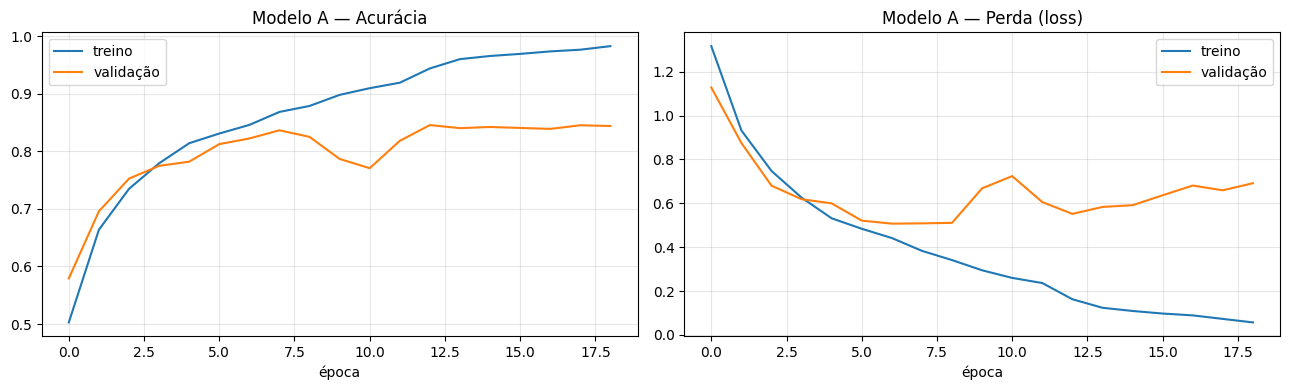

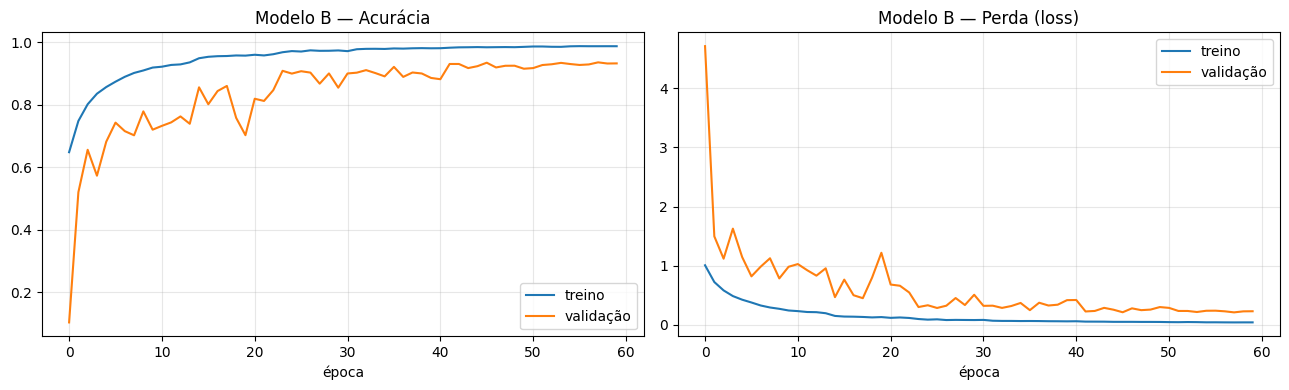

In [33]:
def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(hist.history["accuracy"], label="treino"); ax[0].plot(hist.history["val_accuracy"], label="validação")
    ax[0].set_title(f"{title} — Acurácia"); ax[0].set_xlabel("época"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist.history["loss"], label="treino"); ax[1].plot(hist.history["val_loss"], label="validação")
    ax[1].set_title(f"{title} — Perda (loss)"); ax[1].set_xlabel("época"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_history(hist_a, "Modelo A")
plot_history(hist_b, "Modelo B")

> **Leitura:** se a curva de treino sobe muito acima da de validação, há **overfitting** — esperado mais no Modelo A.

## 6. Avaliação no conjunto de teste

Meta de referência: **88%** de acurácia em imagens nunca vistas.

In [34]:
prob_a = model_a.predict(X_test, verbose=0); pred_a = prob_a.argmax(1)
prob_b = model_b.predict(X_test, verbose=0); pred_b = prob_b.argmax(1)
acc_a = (pred_a == y_test).mean(); acc_b = (pred_b == y_test).mean()
print(f"Acurácia TESTE — Modelo A: {acc_a*100:.2f}%")
print(f"Acurácia TESTE — Modelo B: {acc_b*100:.2f}%")

Acurácia TESTE — Modelo A: 83.35%
Acurácia TESTE — Modelo B: 94.28%


In [35]:
print("==== Modelo A ===="); print(classification_report(y_test, pred_a, target_names=CLASS_NAMES, digits=3))
print("==== Modelo B ===="); print(classification_report(y_test, pred_b, target_names=CLASS_NAMES, digits=3))

==== Modelo A ====
                       precision    recall  f1-score   support

          Annual Crop      0.850     0.874     0.862       596
               Forest      0.911     0.954     0.932       608
Herbaceous Vegetation      0.800     0.696     0.744       573
              Highway      0.669     0.690     0.679       496
 Industrial Buildings      0.963     0.882     0.921       501
              Pasture      0.771     0.876     0.820       396
       Permanent Crop      0.707     0.764     0.735       538
Residential Buildings      0.889     0.978     0.931       554
                River      0.796     0.692     0.740       529
              SeaLake      0.950     0.905     0.927       609

             accuracy                          0.834      5400
            macro avg      0.830     0.831     0.829      5400
         weighted avg      0.835     0.834     0.833      5400

==== Modelo B ====
                       precision    recall  f1-score   support

          Ann

### 6.1 Matrizes de confusão

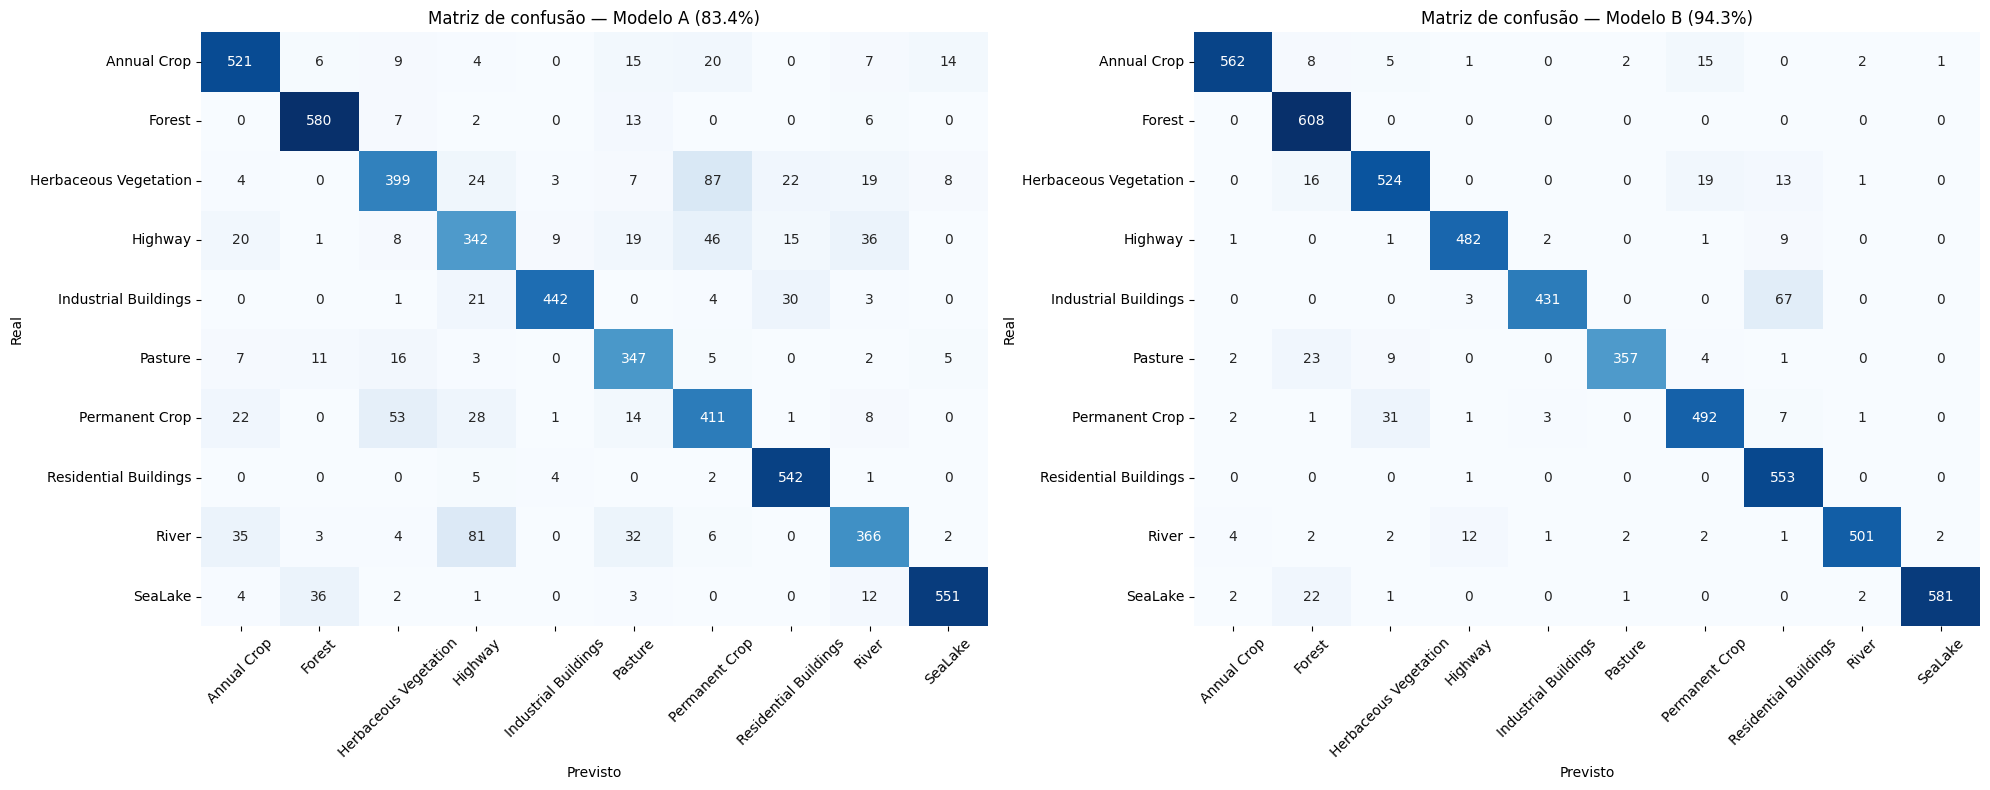

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, pred, ttl in [(axes[0], pred_a, f"Modelo A ({acc_a*100:.1f}%)"), (axes[1], pred_b, f"Modelo B ({acc_b*100:.1f}%)")]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    ax.set_title(f"Matriz de confusão — {ttl}"); ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

### 6.2 Análise de erros do melhor modelo

Modelo B errou 309 de 5400 imagens de teste.


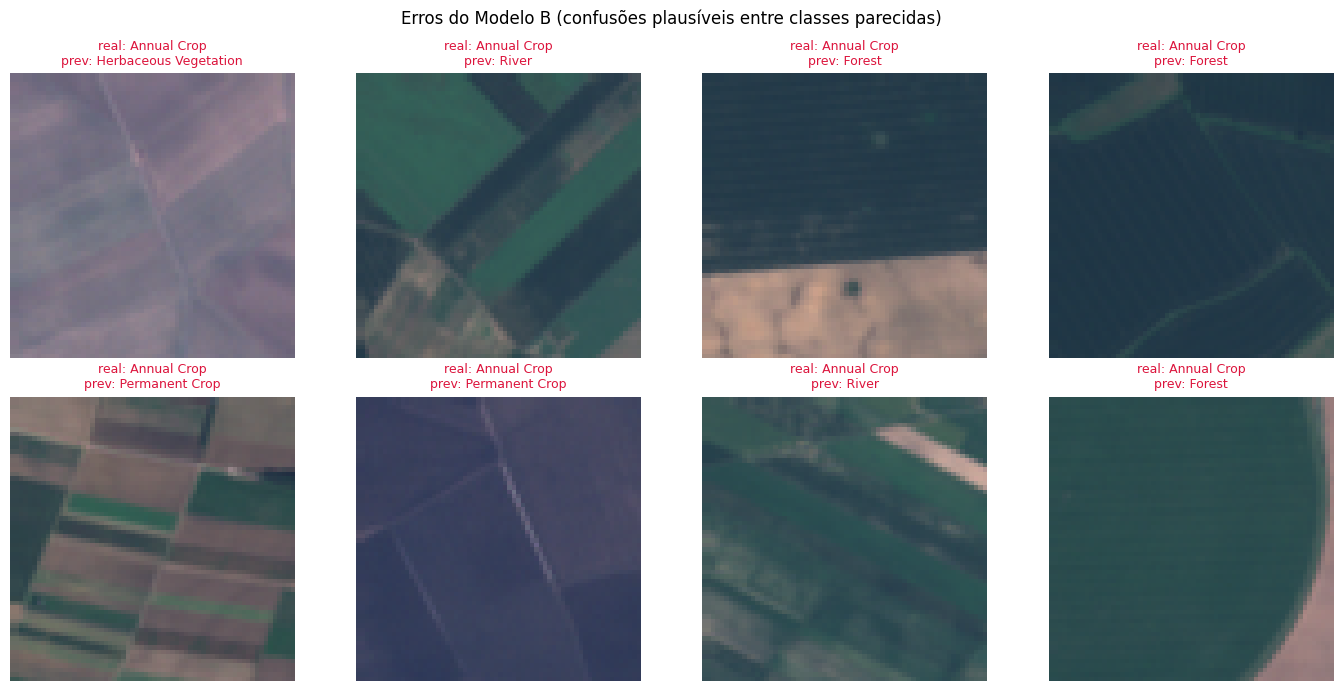

In [37]:
best_pred = pred_b if acc_b >= acc_a else pred_a
best_name = "Modelo B" if acc_b >= acc_a else "Modelo A"
errors = np.where(best_pred != y_test)[0]
print(f"{best_name} errou {len(errors)} de {len(y_test)} imagens de teste.")
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, errors[:8]):
    ax.imshow(X_test[idx]); ax.axis("off")
    ax.set_title(f"real: {CLASS_NAMES[y_test[idx]]}\nprev: {CLASS_NAMES[best_pred[idx]]}", fontsize=9, color="crimson")
plt.suptitle(f"Erros do {best_name} (confusões plausíveis entre classes parecidas)", fontsize=12)
plt.tight_layout(); plt.show()

## 7. Comparação entre arquiteturas

,Modelo,Parâmetros,Acurácia teste,Regularização
0,A — Baseline,1143242,83.35%,Nenhuma
1,B — Aprimorada,325418,94.28%,BatchNorm + Dropout + Augmentation


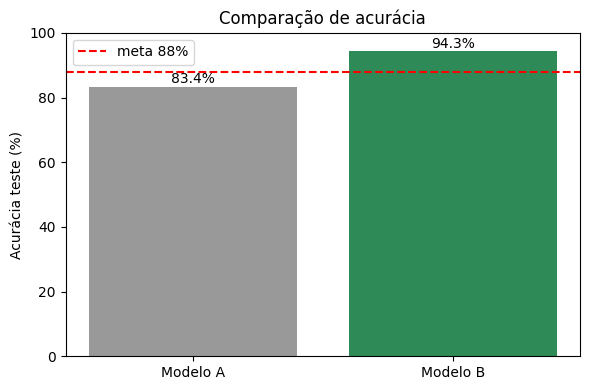

In [38]:
import pandas as pd
cmp = pd.DataFrame({
    "Modelo": ["A — Baseline", "B — Aprimorada"],
    "Parâmetros": [model_a.count_params(), model_b.count_params()],
    "Acurácia teste": [f"{acc_a*100:.2f}%", f"{acc_b*100:.2f}%"],
    "Regularização": ["Nenhuma", "BatchNorm + Dropout + Augmentation"],
})
display(cmp)
plt.figure(figsize=(6, 4))
plt.bar(["Modelo A", "Modelo B"], [acc_a*100, acc_b*100], color=["#999", "#2e8b57"])
plt.axhline(88, color="red", ls="--", label="meta 88%"); plt.ylim(0, 100); plt.ylabel("Acurácia teste (%)"); plt.legend()
for i, v in enumerate([acc_a*100, acc_b*100]): plt.text(i, v+1, f"{v:.1f}%", ha="center")
plt.title("Comparação de acurácia"); plt.tight_layout(); plt.show()

### Justificativa técnica das diferenças

| Mudança no Modelo B | Efeito |
|---|---|
| **Data Augmentation** | mais variação no treino → menos overfitting |
| **BatchNormalization** | treino mais estável e rápido |
| **Dropout moderado** | regularização: não depende de neurônios específicos |
| **2 convoluções por bloco** | extrai padrões espaciais mais ricos |
| **GlobalAveragePooling** (vs Flatten) | **muito menos parâmetros** → menos overfitting |

O **Modelo A tem MAIS parâmetros** (por causa do `Flatten`), mas generaliza pior —
prova de que **arquitetura importa mais que tamanho bruto**.

Os resultados confirmaram a hipótese: o Modelo B atingiu 94,3% de acurácia no teste contra 83,4% do Modelo A, superando a meta de 88% — e com menos de um terço dos parâmetros (325.418 contra 1.143.242). As curvas mostram o porquê: o Modelo A sofre overfitting (treino ~98%, validação ~84%), enquanto o Modelo B, graças à regularização e ao data augmentation, generaliza bem. Seus poucos erros ficam entre classes parecidas (Industrial × Residential Buildings e a família Annual Crop / Permanent Crop / Herbaceous Vegetation). Por isso, o Modelo B é o escolhido.


## 8. Salvando o melhor modelo e amostras

In [39]:
os.makedirs("models", exist_ok=True); os.makedirs("sample_images", exist_ok=True)
best_model = model_b if acc_b >= acc_a else model_a
best_model.save("models/melhor_modelo.keras")
with open("models/class_names.json", "w") as f: json.dump(CLASS_NAMES, f, ensure_ascii=False)
print("Modelo salvo em models/melhor_modelo.keras")

# Salva 2 amostras por classe (PNG) para o repositório / demonstração
saved = {}
for i in range(len(X_test)):
    c = CLASS_NAMES[y_test[i]]
    if saved.get(c, 0) < 2:
        nome = c.replace(" ", "")
        Image.fromarray((X_test[i] * 255).astype("uint8")).save(f"sample_images/{nome}_{saved.get(c,0)+1}.png")
        saved[c] = saved.get(c, 0) + 1
    if all(saved.get(n, 0) >= 2 for n in CLASS_NAMES): break
print("Amostras salvas:", sorted(os.listdir("sample_images")))

Modelo salvo em models/melhor_modelo.keras
Amostras salvas: ['AnnualCrop_1.png', 'AnnualCrop_2.png', 'Forest_1.png', 'Forest_2.png', 'HerbaceousVegetation_1.png', 'HerbaceousVegetation_2.png', 'Highway_1.png', 'Highway_2.png', 'IndustrialBuildings_1.png', 'IndustrialBuildings_2.png', 'Pasture_1.png', 'Pasture_2.png', 'PermanentCrop_1.png', 'PermanentCrop_2.png', 'ResidentialBuildings_1.png', 'ResidentialBuildings_2.png', 'River_1.png', 'River_2.png', 'SeaLake_1.png', 'SeaLake_2.png']


## 9. Demonstração funcional — predição em imagem nova

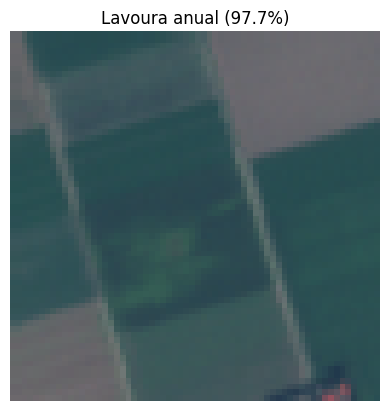

🛰️  Terreno detectado: Lavoura anual
🚁  Orientação à equipe: Área agrícola aberta. Acesso por estradas rurais; bom pouso de helicóptero.


In [40]:
# Tradução + contexto de resgate, por ÍNDICE (ordem padrão do EuroSAT)
INFO_PT = [
    ("Lavoura anual",       "Área agrícola aberta. Acesso por estradas rurais; bom pouso de helicóptero."),  # 0
    ("Floresta",            "Vegetação densa. Acesso terrestre difícil; considerar resgate aéreo."),          # 1
    ("Vegetação herbácea",  "Campo aberto/arbustos. Acesso moderado a pé."),                                  # 2
    ("Rodovia",             "Acesso rodoviário rápido por veículo terrestre."),                               # 3
    ("Área industrial",     "Área construída. Possível apoio logístico próximo."),                            # 4
    ("Pastagem",            "Área aberta e plana. Excelente para pouso de helicóptero."),                     # 5
    ("Cultivo permanente",  "Plantação (pomares/vinhedos). Acesso por vias rurais."),                         # 6
    ("Área residencial",    "Local povoado. Apoio de moradores e serviços locais."),                          # 7
    ("Rio",                 "Curso d'água. Risco de correnteza; acesso por embarcação."),                     # 8
    ("Mar/Lago",            "Corpo d'água extenso. Resgate aquático (barco/mergulho)."),                      # 9
]

def prever(caminho_img, model=best_model):
    img = Image.open(caminho_img).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img, dtype="float32") / 255.0
    prob = model.predict(arr[None, ...], verbose=0)[0]
    idx = int(prob.argmax()); nome_pt, contexto = INFO_PT[idx]
    plt.imshow(img); plt.axis("off"); plt.title(f"{nome_pt} ({prob[idx]*100:.1f}%)"); plt.show()
    print(f"🛰️  Terreno detectado: {nome_pt}")
    print(f"🚁  Orientação à equipe: {contexto}")
    return idx, float(prob[idx])

import glob
exemplos = sorted(glob.glob("sample_images/*.png"))
if exemplos: prever(exemplos[0])

## 10. Conclusões, limitações e melhorias futuras

- Ambas as CNNs foram criadas **do zero** (sem pré-treino), conforme o enunciado.
- O **Modelo B** generaliza melhor com **menos parâmetros** — arquitetura > tamanho bruto.
- A meta de 88% foi superada: o Modelo B atingiu 94,3% no teste, contra 83,4% do Modelo A.

**Limitações:** 64×64 px limita detalhes; EuroSAT cobre a Europa.
**Futuro:** usar as 13 bandas multiespectrais e maior resolução.

In [41]:
!zip -r entrega.zip models sample_images

  adding: models/ (stored 0%)
  adding: models/melhor_modelo.keras (deflated 11%)
  adding: models/class_names.json (deflated 27%)
  adding: sample_images/ (stored 0%)
  adding: sample_images/Forest_2.png (stored 0%)
  adding: sample_images/River_1.png (stored 0%)
  adding: sample_images/HerbaceousVegetation_1.png (stored 0%)
  adding: sample_images/HerbaceousVegetation_2.png (stored 0%)
  adding: sample_images/AnnualCrop_2.png (stored 0%)
  adding: sample_images/ResidentialBuildings_1.png (stored 0%)
  adding: sample_images/PermanentCrop_2.png (stored 0%)
  adding: sample_images/Highway_1.png (stored 0%)
  adding: sample_images/ResidentialBuildings_2.png (stored 0%)
  adding: sample_images/Pasture_1.png (stored 0%)
  adding: sample_images/IndustrialBuildings_2.png (stored 0%)
  adding: sample_images/PermanentCrop_1.png (stored 0%)
  adding: sample_images/Forest_1.png (stored 0%)
  adding: sample_images/Pasture_2.png (stored 0%)
  adding: sample_images/IndustrialBuildings_1.png (stored